29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training Data Shape : (60000, 28, 28)
Testing Data Shape  : (10000, 28, 28)


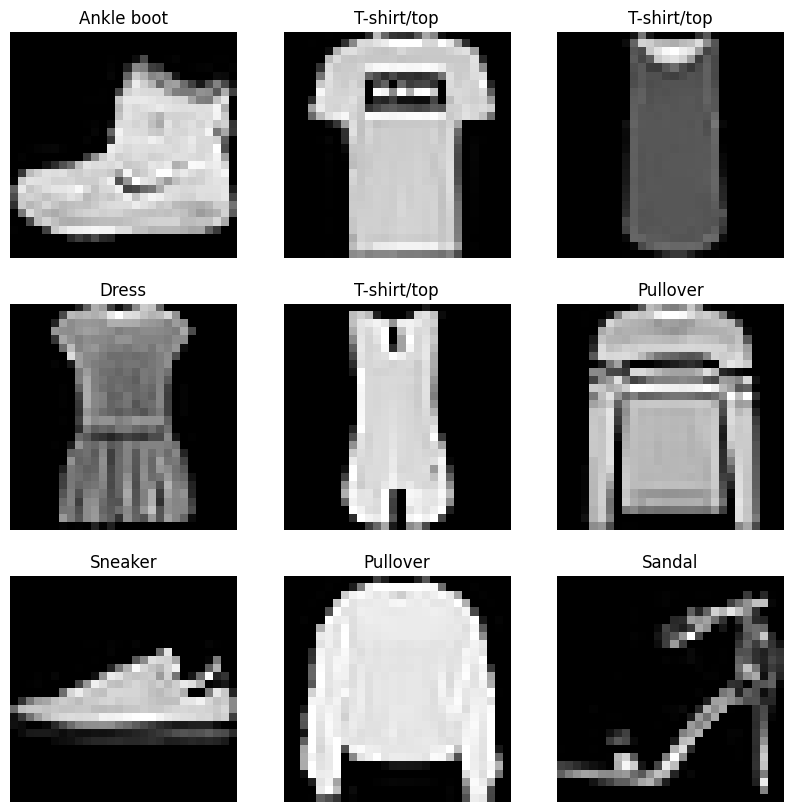

Training Shape   : (48000, 28, 28)
Validation Shape : (12000, 28, 28)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8008 - loss: 0.5586 - val_accuracy: 0.8534 - val_loss: 0.4062
Epoch 2/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8494 - loss: 0.4137 - val_accuracy: 0.8615 - val_loss: 0.3819
Epoch 3/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8612 - loss: 0.3767 - val_accuracy: 0.8643 - val_loss: 0.3727
Epoch 4/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8692 - loss: 0.3561 - val_accuracy: 0.8778 - val_loss: 0.3383
Epoch 5/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8749 - loss: 0.3401 - val_accuracy: 0.8739 - val_loss: 0.3427
Epoch 6/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8798 - loss: 0.3262 - val_accuracy: 0.8718 - val_loss: 0.3542
Epoch 7/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8824 - loss: 0.3169 - val_accuracy: 0.8772 - val_loss: 0.3364
Epoch 8/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8848 - loss: 0.3068 - 

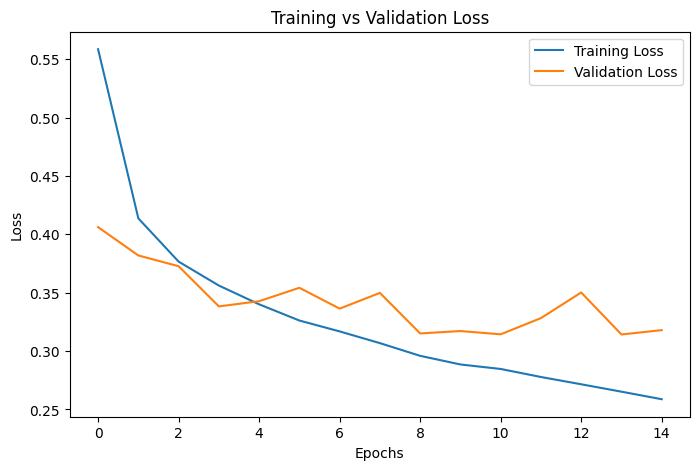

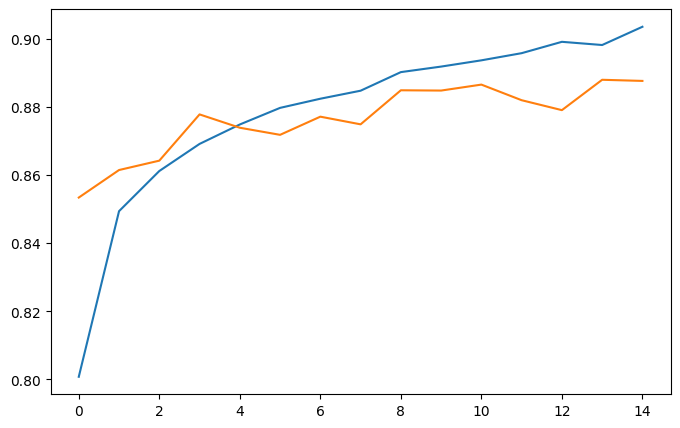

In [3]:
# =========================================================
# NEURAL NETWORKS PROJECT
# Fashion-MNIST Classification using MLP
# =========================================================


# =========================================================
# 1. IMPORT LIBRARIES
# =========================================================

import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.utils import to_categorical

from sklearn.model_selection import train_test_split


# =========================================================
# 2. LOAD DATASET
# =========================================================

(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

print("Training Data Shape :", X_train.shape)
print("Testing Data Shape  :", X_test.shape)


# =========================================================
# 3. DISPLAY SAMPLE IMAGES
# =========================================================

class_names = [
    'T-shirt/top',
    'Trouser',
    'Pullover',
    'Dress',
    'Coat',
    'Sandal',
    'Shirt',
    'Sneaker',
    'Bag',
    'Ankle boot'
]

plt.figure(figsize=(10,10))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(class_names[y_train[i]])
    plt.axis('off')

plt.show()


# =========================================================
# 4. PREPROCESSING
# =========================================================

# NORMALIZATION

X_train = X_train / 255.0
X_test = X_test / 255.0


# ONE HOT ENCODING

y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)


# =========================================================
# 5. TRAIN / VALIDATION SPLIT
# =========================================================

X_train, X_val, y_train_cat, y_val_cat = train_test_split(
    X_train,
    y_train_cat,
    test_size=0.2,
    random_state=42
)

print("Training Shape   :", X_train.shape)
print("Validation Shape :", X_val.shape)


# =========================================================
# 6. BUILD FIRST MLP MODEL
# =========================================================

model = Sequential([

    Flatten(input_shape=(28,28)),

    Dense(128, activation='relu'),

    Dropout(0.2),

    Dense(64, activation='relu'),

    Dense(10, activation='softmax')
])

model.summary()


# =========================================================
# 7. COMPILE MODEL
# =========================================================

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


# =========================================================
# 8. TRAIN MODEL
# =========================================================

history = model.fit(
    X_train,
    y_train_cat,
    epochs=15,
    batch_size=32,
    validation_data=(X_val, y_val_cat)
)


# =========================================================
# 9. EVALUATE MODEL
# =========================================================

test_loss, test_accuracy = model.evaluate(X_test, y_test_cat)

print("\n========== FIRST EXPERIMENT ==========")
print("Test Loss     :", test_loss)
print("Test Accuracy :", test_accuracy)


# =========================================================
# 10. LOSS CURVE
# =========================================================

plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.legend()
plt.show()


# =========================================================
# 11. ACCURACY CURVE
# =========================================================

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')